In [14]:
%pip -q install gradio torchmetrics
import os
import random
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.utils as vutils

amp_device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(amp_device)
print('Device:', device)
if torch.cuda.is_available():
    print('GPU count:', torch.cuda.device_count())

Note: you may need to restart the kernel to use updated packages.
Device: cuda
GPU count: 2


In [15]:
@dataclass
class CFG:
    DATA_ROOT = Path('/kaggle/input/datasets/jackemartin/pokemon-sprites')  # change to anime faces path if needed
    IMAGE_SIZE = 64
    Z_DIM = 100
    BATCH_SIZE = 64
    EPOCHS_DCGAN = 20
    EPOCHS_WGAN = 20
    LR = 2e-4
    BETAS = (0.5, 0.999)
    NUM_WORKERS = 2
    LAMBDA_GP = 10.0
    CRITIC_UPDATES = 5
    CHECKPOINT_EVERY = 5
    SUBSET_RATIO = 1.0  # reduce for fast experiments
    OUTDIR = Path('/kaggle/working/q1_outputs')

CFG.OUTDIR.mkdir(parents=True, exist_ok=True)
print(CFG)

<class '__main__.CFG'>


In [19]:
class RecursiveImageDataset(Dataset):
    def __init__(self, root, image_size=64, subset_ratio=1.0):
        self.root = Path(root)
        exts = {'.png', '.jpg', '.jpeg', '.webp', '.bmp'}
        self.paths = [p for p in self.root.rglob('*') if p.suffix.lower() in exts]
        if len(self.paths) == 0:
            raise FileNotFoundError(f'No images found under {self.root}')
        random.shuffle(self.paths)
        keep = max(1, int(len(self.paths) * subset_ratio))
        self.paths = self.paths[:keep]
        self.tfms = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx])
        if img.mode == 'P' and 'transparency' in img.info:
            img = img.convert('RGBA')
        img = img.convert('RGB')
        return self.tfms(img)

dataset = RecursiveImageDataset(CFG.DATA_ROOT, CFG.IMAGE_SIZE, CFG.SUBSET_RATIO)
loader = DataLoader(dataset, batch_size=CFG.BATCH_SIZE, shuffle=True,
                    num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
print('Images:', len(dataset), 'Batches:', len(loader))

Images: 33887 Batches: 529


In [20]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, z_dim=100, ngf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False)
        )
    def forward(self, x):
        return self.net(x).view(-1)

class Critic(Discriminator):
    pass

In [21]:
@torch.no_grad()
def save_samples(G, fixed_noise, file_path):
    G.eval()
    fake = G(fixed_noise).cpu()
    grid = vutils.make_grid(fake, nrow=4, normalize=True, value_range=(-1,1))
    vutils.save_image(grid, file_path)

def gradient_penalty(critic, real, fake):
    bsz = real.size(0)
    eps = torch.rand(bsz, 1, 1, 1, device=real.device)
    inter = eps * real + (1 - eps) * fake
    inter.requires_grad_(True)
    scores = critic(inter)
    grad = torch.autograd.grad(outputs=scores, inputs=inter,
                               grad_outputs=torch.ones_like(scores),
                               create_graph=True, retain_graph=True)[0]
    grad = grad.view(bsz, -1)
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()

def plot_losses(history, title):
    plt.figure(figsize=(10,4))
    for k, v in history.items():
        plt.plot(v, label=k)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [22]:
def train_dcgan(loader, epochs=20):
    G = Generator(CFG.Z_DIM).to(device); G.apply(weights_init)
    D = Discriminator().to(device); D.apply(weights_init)
    optG = optim.Adam(G.parameters(), lr=CFG.LR, betas=CFG.BETAS)
    optD = optim.Adam(D.parameters(), lr=CFG.LR, betas=CFG.BETAS)
    bce = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    fixed_noise = torch.randn(16, CFG.Z_DIM, 1, 1, device=device)
    hist = {'G_loss': [], 'D_loss': []}

    for epoch in range(1, epochs+1):
        g_running, d_running = 0.0, 0.0
        for real in loader:
            real = real.to(device, non_blocking=True)
            bsz = real.size(0)
            real_lbl = torch.ones(bsz, device=device)
            fake_lbl = torch.zeros(bsz, device=device)

            # D step
            optD.zero_grad(set_to_none=True)
            z = torch.randn(bsz, CFG.Z_DIM, 1, 1, device=device)
            with torch.amp.autocast(device_type=amp_device, enabled=torch.cuda.is_available()):
                fake = G(z).detach()
                d_real = D(real)
                d_fake = D(fake)
                d_loss = bce(d_real, real_lbl) + bce(d_fake, fake_lbl)
            scaler.scale(d_loss).backward()
            scaler.step(optD)
            scaler.update()

            # G step
            optG.zero_grad(set_to_none=True)
            z = torch.randn(bsz, CFG.Z_DIM, 1, 1, device=device)
            with torch.amp.autocast(device_type=amp_device, enabled=torch.cuda.is_available()):
                fake = G(z)
                g_loss = bce(D(fake), real_lbl)
            scaler.scale(g_loss).backward()
            scaler.step(optG)
            scaler.update()

            g_running += g_loss.item()
            d_running += d_loss.item()

        hist['G_loss'].append(g_running / len(loader))
        hist['D_loss'].append(d_running / len(loader))
        print(f'[DCGAN] Epoch {epoch}/{epochs} | G: {hist["G_loss"][-1]:.4f} | D: {hist["D_loss"][-1]:.4f}')

        if torch.cuda.is_available():
            mem = torch.cuda.memory_allocated() / (1024**3)
            print(f'GPU memory allocated: {mem:.2f} GB')

        save_samples(G, fixed_noise, CFG.OUTDIR / f'dcgan_samples_epoch_{epoch}.png')
        if epoch % CFG.CHECKPOINT_EVERY == 0:
            torch.save({'G': G.state_dict(), 'D': D.state_dict(), 'hist': hist},
                       CFG.OUTDIR / f'dcgan_ckpt_epoch_{epoch}.pt')

    return G, D, hist

def train_wgan_gp(loader, epochs=20):
    G = Generator(CFG.Z_DIM).to(device); G.apply(weights_init)
    C = Critic().to(device); C.apply(weights_init)
    optG = optim.Adam(G.parameters(), lr=CFG.LR, betas=CFG.BETAS)
    optC = optim.Adam(C.parameters(), lr=CFG.LR, betas=CFG.BETAS)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    fixed_noise = torch.randn(16, CFG.Z_DIM, 1, 1, device=device)
    hist = {'G_loss': [], 'C_loss': []}

    for epoch in range(1, epochs+1):
        g_running, c_running = 0.0, 0.0
        for real in loader:
            real = real.to(device, non_blocking=True)
            bsz = real.size(0)

            # Critic updates
            c_loss_running = 0.0
            for _ in range(CFG.CRITIC_UPDATES):
                optC.zero_grad(set_to_none=True)
                z = torch.randn(bsz, CFG.Z_DIM, 1, 1, device=device)
                with torch.amp.autocast(device_type=amp_device, enabled=torch.cuda.is_available()):
                    fake = G(z).detach()
                    c_real = C(real).mean()
                    c_fake = C(fake).mean()
                gp = gradient_penalty(C, real, fake)
                c_loss = -(c_real - c_fake) + CFG.LAMBDA_GP * gp
                scaler.scale(c_loss).backward()
                scaler.step(optC)
                scaler.update()
                c_loss_running += c_loss.item()

            # Generator update
            optG.zero_grad(set_to_none=True)
            z = torch.randn(bsz, CFG.Z_DIM, 1, 1, device=device)
            with torch.amp.autocast(device_type=amp_device, enabled=torch.cuda.is_available()):
                fake = G(z)
                g_loss = -C(fake).mean()
            scaler.scale(g_loss).backward()
            scaler.step(optG)
            scaler.update()

            g_running += g_loss.item()
            c_running += c_loss_running / CFG.CRITIC_UPDATES

        hist['G_loss'].append(g_running / len(loader))
        hist['C_loss'].append(c_running / len(loader))
        print(f'[WGAN-GP] Epoch {epoch}/{epochs} | G: {hist["G_loss"][-1]:.4f} | C: {hist["C_loss"][-1]:.4f}')

        if torch.cuda.is_available():
            mem = torch.cuda.memory_allocated() / (1024**3)
            print(f'GPU memory allocated: {mem:.2f} GB')

        save_samples(G, fixed_noise, CFG.OUTDIR / f'wgangp_samples_epoch_{epoch}.png')
        if epoch % CFG.CHECKPOINT_EVERY == 0:
            torch.save({'G': G.state_dict(), 'C': C.state_dict(), 'hist': hist},
                       CFG.OUTDIR / f'wgangp_ckpt_epoch_{epoch}.pt')

    return G, C, hist

In [23]:
# Training baseline then improved model
dcgan_G, dcgan_D, hist_dcgan = train_dcgan(loader, epochs=CFG.EPOCHS_DCGAN)
wgan_G, wgan_C, hist_wgan = train_wgan_gp(loader, epochs=CFG.EPOCHS_WGAN)

[DCGAN] Epoch 1/20 | G: 6.9961 | D: 0.4775
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 2/20 | G: 3.5532 | D: 0.6521
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 3/20 | G: 3.5128 | D: 0.6100
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 4/20 | G: 3.4799 | D: 0.5927
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 5/20 | G: 3.1581 | D: 0.6282
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 6/20 | G: 2.9188 | D: 0.6597
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 7/20 | G: 3.0162 | D: 0.6240
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 8/20 | G: 3.2239 | D: 0.5472
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 9/20 | G: 3.4713 | D: 0.5124
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 10/20 | G: 3.3641 | D: 0.4808
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 11/20 | G: 3.5243 | D: 0.4663
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 12/20 | G: 3.6705 | D: 0.3973
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 13/20 | G: 3.8451 | D: 0.3567
GPU memory allocated: 0.20 GB
[DCGAN] Epoch 14/20 | G: 4.1000 | D: 0.3563
GPU

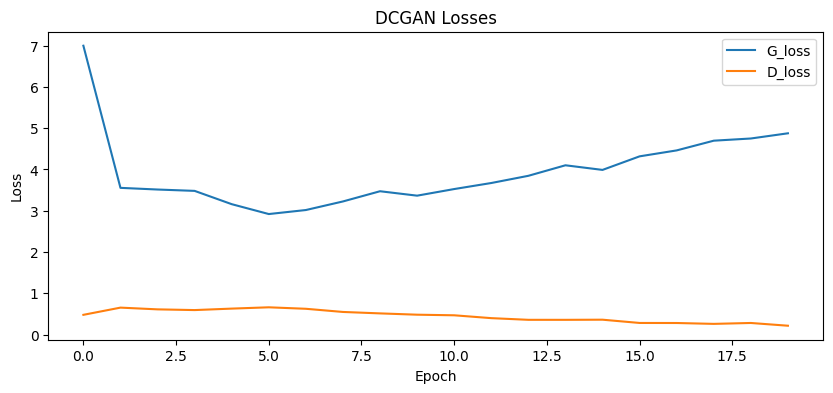

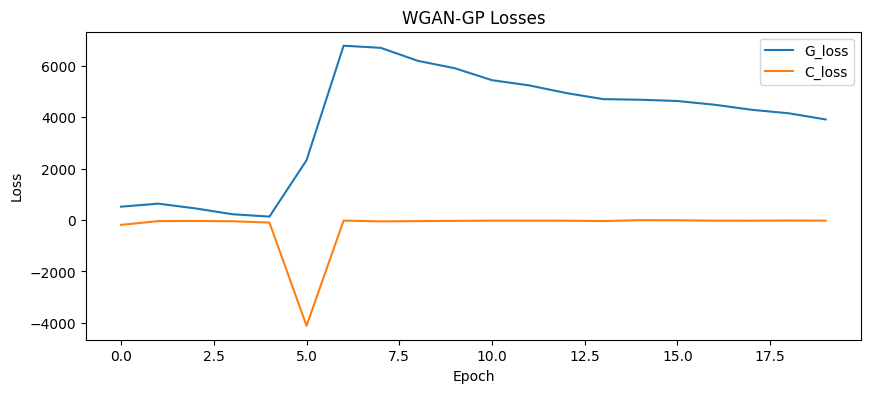

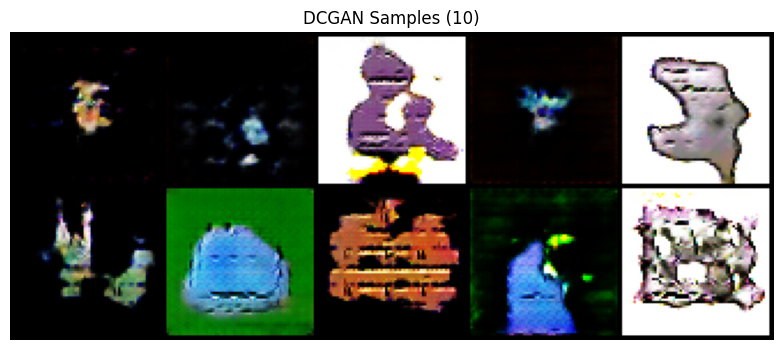

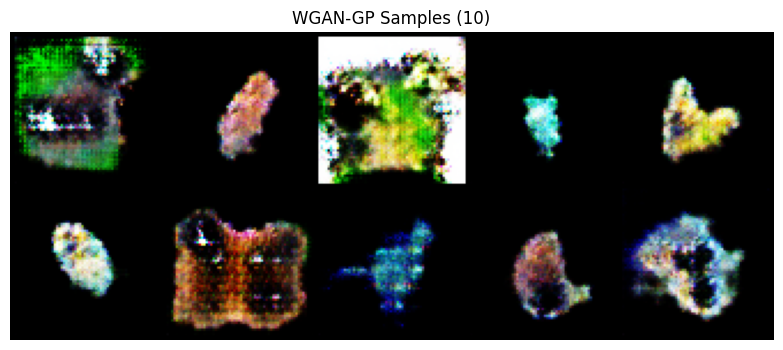

In [24]:
plot_losses(hist_dcgan, 'DCGAN Losses')
plot_losses(hist_wgan, 'WGAN-GP Losses')

@torch.no_grad()
def show_model_samples(G, title, n=10):
    G.eval()
    z = torch.randn(n, CFG.Z_DIM, 1, 1, device=device)
    fake = G(z).cpu()
    grid = vutils.make_grid(fake, nrow=5, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(10,4))
    plt.title(title)
    plt.axis('off')
    plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
    plt.show()

show_model_samples(dcgan_G, 'DCGAN Samples (10)')
show_model_samples(wgan_G, 'WGAN-GP Samples (10)')

In [25]:
                                                
@torch.no_grad()
def diversity_score(G, n=64):
    G.eval()
    z = torch.randn(n, CFG.Z_DIM, 1, 1, device=device)
    x = G(z).flatten(1)
    d = torch.cdist(x, x, p=1)
    return d.mean().item()

dc_div = diversity_score(dcgan_G)
wg_div = diversity_score(wgan_G)
print(f'Diversity (higher is better) - DCGAN: {dc_div:.2f}, WGAN-GP: {wg_div:.2f}')
print('Optional: add clean-fid for FID/IS if required by instructor.')

Diversity (higher is better) - DCGAN: 8158.33, WGAN-GP: 9937.96
Optional: add clean-fid for FID/IS if required by instructor.
